Welcome to the benchmark tutorial notebook for the **On Top of Pasketti: Children’s Speech Recognition Challenge - Word Track**! If you are just getting started, we recommend reading the [competition webpage](https://www.drivendata.org/competitions/308/childrens-word-asr/) first. 

The goal of this tutorial is to: 
1. Demonstrate how to [load and explore the data](#-Step-1:-Load-and-explore-the-data).
2. Provide a basic framework for [building a model](#-Step-2:-Build-the-model).
3. Demonstrate how to [package your work](#-Step-3:-Make-your-submission) correctly for submission.


In this tutorial, we will [adapt](https://github.com/NVIDIA-NeMo/NeMo/tree/main/examples/asr/asr_adapters) NVIDIA's Parakeet model, a pretrained ASR model, using [NeMo](https://docs.nvidia.com/nemo-framework/user-guide/latest/nemotoolkit/asr/intro.html). You can either expand on and improve the method in this benchmark, or start with something completely different! Let's get started.

___

## Background

Spoken language is a natural way for kids to learn, explore, and show what they know, yet today's Automatic Speech Recognition (ASR) technology hardly understands them. Most ASR systems are built on adult speech, and struggle with the pitch, rhythm, and evolving articulation of young learners.

The [On Top of Pasketti: Children’s Speech Recognition Challenge](https://www.drivendata.org/competitions/group/childrens-asr-competition/) assembles pre-existing and newly labeled datasets to advance speech models that truly work for children. Your goal in the [Word Track](https://www.drivendata.org/competitions/308/childrens-word-asr/) is to develop models that accurately predict the words spoken by children in short audio clips.

This is a [code execution challenge](https://drivendata.co/blog/code-execution-competitions)! Rather than submitting your predicted labels, you will package your trained model and the prediction code and submit that for containerized execution. See the [code submission format](https://www.drivendata.org/competitions/308/childrens-word-asr/page/978/) webpage and the [runtime repository](https://github.com/drivendataorg/childrens-speech-recognition-runtime/tree/main) for more information. 

If you'd like to rerun this notebook, the notebook file can be downloaded from the [benchmark repository](https://github.com/drivendataorg/childrens-speech-recognition-benchmark-pub). That repository also includes all code imported into the notebook.

___

# Step 0: Import packages

First, create your environment. We use `uv` as the package manager in this benchmark repository.

1. Create an environment: `just create-environment`
2. Activate the environment: `source ./.venv/bin/activate`
3. Install the requirements found in the [TOML file](https://github.com/drivendataorg/childrens-speech-recognition-benchmark-pub/blob/main/pyproject.toml) into the environment: `just requirements`

Remember, the runtime repository's [TOML file](https://github.com/drivendataorg/childrens-speech-recognition-runtime/blob/main/runtime/pyproject.toml) lists the packages that will be available for running inference using model submissions.

We'll be using NVIDIA's NeMo framework to build our model along with standard data science Python libraries to explore and prepare the data. Because this is a code execution challenge, we'll also be testing our solutions locally before packaging our model and inference code for submission. To help us with scoring, we've imported some utility functions from the competition's [runtime repository](https://github.com/drivendataorg/childrens-speech-recognition-runtime).

In [1]:
# Standard library
import json
import os
from pathlib import Path

# Visualization
import matplotlib.pyplot as plt
from matplotlib import ticker

# Core ML & audio stack
import librosa
import lightning.pytorch as pl
import numpy as np
import pandas as pd
import torch

# ASR models & normalization
from nemo.collections.asr.models import ASRModel
from transformers.models.whisper.english_normalizer import EnglishTextNormalizer

# Training & experiment utilities
from loguru import logger
from nemo.utils import logging
from nemo.utils.exp_manager import exp_manager
from nemo.utils.trainer_utils import resolve_trainer_cfg
from omegaconf import OmegaConf, open_dict
from sklearn.model_selection import train_test_split

# Project utilities
from asr_benchmark.config import DATA_ROOT, PROJECT_ROOT
from asr_benchmark.nemo_adapter import (
    add_global_adapter_cfg,
    patch_transcribe_lhotse,
    update_model_cfg,
    update_model_config_to_support_adapter,
)
from asr_benchmark.score import english_spelling_normalizer, score_wer

fused_indices_to_multihot has reached end of life. Please migrate to a non-experimental function.
OneLogger: Setting error_handling_strategy to DISABLE_QUIETLY_AND_REPORT_METRIC_ERROR for rank (rank=0) with OneLogger disabled. To override: explicitly set error_handling_strategy parameter.
No exporters were provided. This means that no telemetry data will be collected.
[NeMo W 2026-03-23 16:14:29 nemo_logging:405] /home/bikki2/projects/childrens-speech-recognition-benchmark-pub/.venv/lib/python3.11/site-packages/pydub/utils.py:170: RuntimeWarning: Couldn't find ffmpeg or avconv - defaulting to ffmpeg, but may not work
      warn("Couldn't find ffmpeg or avconv - defaulting to ffmpeg, but may not work", RuntimeWarning)
    


In [2]:
torch.set_float32_matmul_precision("high")
# Set SAMPLE to use a smaller subset of the data for faster iteration during development. Set it to None to use the full dataset.
SAMPLE = None

___
# Step 1: Load and explore the data

First, you'll likely want to set up your own repository for developing a solution.  We recommend using [Cookiecutter Data Science](https://cookiecutter-data-science.drivendata.org/), which ensures an easy-to-navigate project structure.

We'll download all of the competition data to our "raw" folder. There are two distinct training corpora that share the same structure but contain different data, and are hosted in separate locations for participant access. One corpus is hosted on the DrivenData platform, while a second corpus, which follows the same schema but contains different data, is provided by TalkBank. See the [Data Download](https://www.drivendata.org/competitions/308/childrens-word-asr/data/) page for access instructions.

Our local data structure after downloading all files to a raw data folder is:

```bash
    childrens-speech-recognition-benchmark-pub/data/raw
    ├── drivendata
    │   ├── audio_part_0.zip
    │   ├── audio_part_1.zip
    │   ├── audio_part_2.zip
    │   └── train_word_transcripts.jsonl
    └── talkbank
        ├── audio.zip
        └── train_word_transcripts.jsonl
```

After unzipping the files, you may want to consolidate the audio files into a single "audio" folder within the drivendata directory, where audio are split into multiple zip files.

```bash
rsync -a ./data/raw/drivendata/"audio 3"/ ./data/raw/drivendata/audio/
```

```bash
    childrens-speech-recognition-benchmark-pub/data/raw
    ├── drivendata
    │   ├── audio/
    │   ├── audio_part_0.zip
    │   ├── audio_part_1.zip
    │   ├── audio_part_2.zip
    │   └── train_word_transcripts.jsonl
    └── talkbank
        ├── audio/
        ├── audio.zip
        └── train_word_transcripts.jsonl
```

For each of the two corpora, the file train_word_transcripts.jsonl contains the following fields:
* `utterance_id` (str) - unique identifier for each utterance
* `child_id` (str) - unique, anonymized identifier for the speaker
* `session_id` (str) - unique identifier for the recording session; a single child_id may be associated with multiple session_ids
* `audio_path` (str) - path to the corresponding .flac audio file relative to the /audio directory, following the pattern audio/{utterance_id}.flac
* `audio_duration_sec` (float) - duration of the audio clip in seconds
* `age_bucket` (str) - age range of the child at the time of recording ("3-4", "5-7", "8-11", "12+", or "unknown")
* `md5_hash` (str) - MD5 checksum of the audio file, used for integrity verification
* `filesize_bytes` (int) - size of the audio file in bytes
* `orthographic_text` (str) - normalized orthographic transcription of the utterance

Each line in the JSONL manifest corresponds to a single utterance and references exactly one associated audio file. The `orthographic_text` field contains a manually created, minimally normalized orthographic transcription that serves as the training label.

## Let's explore the metadata!

We will load the JSONL transcripts and explore some of the metadata. As a starting point, it is helpful to know how many utterances we have, how many unique children are present, the total audio time, the distribution of audio clip durations, and the distribution of child ages.

In [3]:
def read_transcripts(data_dir: Path) -> pd.DataFrame:
    """Read JSONL transcript file into a DataFrame and convert audio paths to absolute paths."""
    transcript_path = data_dir / "train_word_transcripts.jsonl"
    df = pd.read_json(transcript_path, lines=True)
    logger.info(f"Loaded {len(df)} utterance transcripts")

    df["audio_relpath"] = df["audio_path"]
    df["audio_path"] = df["audio_relpath"].map(lambda p: str(data_dir / p))

    return df

In [4]:
df_dd = read_transcripts(DATA_ROOT / "raw" / "drivendata")
df_tb = read_transcripts(DATA_ROOT / "raw" / "talkbank" / "audio")
df = pd.concat([df_dd, df_tb], ignore_index=True)
print(df.shape)
df.drop(columns=["audio_path"]).head()

2026-03-23 16:15:04.726 | INFO     | __main__:read_transcripts:5 - Loaded 95572 utterance transcripts
2026-03-23 16:15:05.691 | INFO     | __main__:read_transcripts:5 - Loaded 255046 utterance transcripts


(350618, 10)


,utterance_id,child_id,session_id,audio_duration_sec,age_bucket,md5_hash,filesize_bytes,orthographic_text,audio_relpath
0,U_00003c3ae1c35c6f,C_c74bfde2cca8d5da,S_7d821c3e4d3bc616,1.920,8-11,9214be45ba2928dd57384f3c7ee54236,30672,hm,audio/U_00003c3ae1c35c6f.flac
1,U_00003db24218ffe4,C_c74bfde2cca8d5da,S_e6103ab3a4538d71,12.737,8-11,fe761bb3d034530ef05163c7ad98ec3e,180942,yeah its pouring the water on the screen but t...,audio/U_00003db24218ffe4.flac
2,U_0001a0d0a3b4d816,C_4d0e1c16566d65a2,S_179057c3c3ccdecf,11.556,8-11,b05073e65a98368fccbe777b5ab35e02,208352,it got water and sunlight but the plant did di...,audio/U_0001a0d0a3b4d816.flac
3,U_00021d201a31d313,C_3b51c8b1d2c076d8,S_90720887e4430996,1.125,8-11,9ed95318724ae6a2d1ce95d6aa743f6b,27099,there is wires,audio/U_00021d201a31d313.flac
4,U_0003537f2bc1eb0b,C_b50216b3c70ca0a2,S_5b0bb48fadd7f802,1.125,8-11,f3142751c6a52e2c24a85a4544fe8a0f,18476,good,audio/U_0003537f2bc1eb0b.flac


In [5]:
df.utterance_id.nunique()

350618

In [6]:
df.child_id.nunique()

3344

In [7]:
round(df.audio_duration_sec.sum() / (60**2))

344

There are over 350,000 utterances in the training dataset, across 3,344 children, totaling 344 hours of audio data. Next, let's take a look at the distribution of audio clip durations.

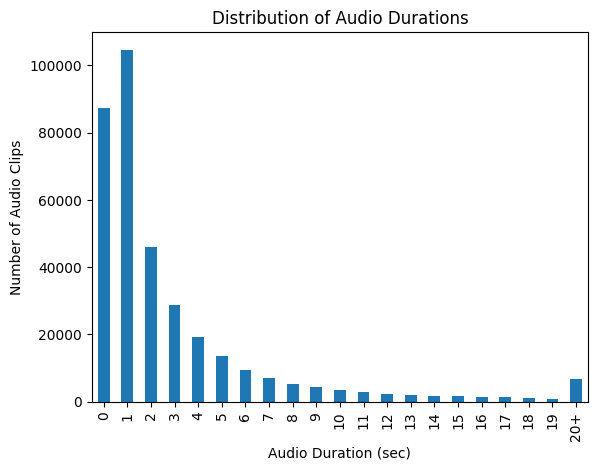

In [8]:
bins = list(range(0, 21)) + [np.inf]
labels = [str(i) for i in range(0, 20)] + ["20+"]

binned = pd.cut(df.audio_duration_sec, bins=bins, labels=labels, right=False)
counts = binned.value_counts().sort_index()

counts.plot(kind="bar")
plt.xlabel("Audio Duration (sec)")
plt.ylabel("Number of Audio Clips")
plt.title("Distribution of Audio Durations")
plt.xticks(rotation=90)
plt.show()

Even though the audio has been clipped to the utterance level, we have some outliers over 20 seconds.

In [9]:
# What is the longest clip (in minutes)?
round(df.audio_duration_sec.max() / 60)

22

Most audio clips are very short (1-3 seconds). There is a tail of longer clips, up to an outlier 22 minute clip. Next, let's look at the distribution of utterances by child age.

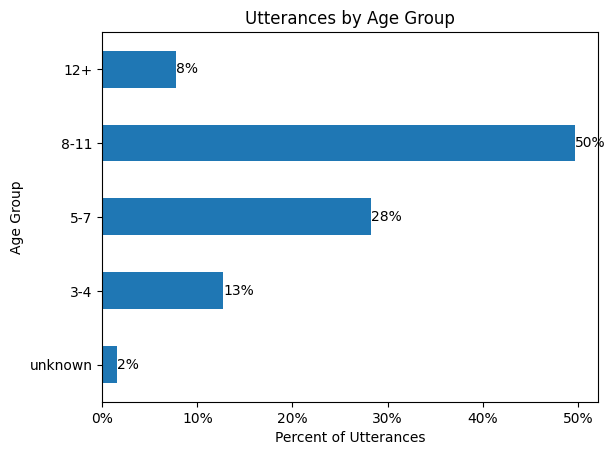

In [10]:
df["age_bucket"] = pd.Categorical(
    df["age_bucket"], categories=["unknown", "3-4", "5-7", "8-11", "12+"], ordered=True
)

fig, ax = plt.subplots()
df["age_bucket"].value_counts(normalize=True, sort=False).plot.barh(ax=ax)
ax.set_title("Utterances by Age Group")
ax.set_xlabel("Percent of Utterances")
ax.set_ylabel("Age Group")
ax.xaxis.set_major_formatter(ticker.PercentFormatter(1.0))
ax.bar_label(ax.containers[0], fmt=lambda x: f"{x * 100:.0f}%")

plt.show()

About half of the utterances come from 8 to 11 year olds, with 13% coming from 3 to 4 year olds and 28% coming from 5 to 7 year olds.

## Let’s explore the utterances!

We will listen to an example utterance and visualize the features.

In [11]:
def plot_waveform(audio_data: np.ndarray, sr: int) -> None:
    """Plot the waveform of an audio signal"""
    plt.figure(figsize=(10, 4))
    librosa.display.waveshow(audio_data, sr=sr)
    plt.title("Waveform")
    plt.xlabel("Time (s)")
    plt.ylabel("Amplitude")
    plt.show()

In [12]:
def plot_melspectrogram(audio_data: np.ndarray, sr: int) -> None:
    """Generate and plot the mel spectrogram of an audio signal"""
    S = librosa.feature.melspectrogram(y=audio_data, sr=sr)
    S_db = librosa.power_to_db(S, ref=np.max)

    plt.figure(figsize=(10, 4))
    librosa.display.specshow(S_db, sr=sr, x_axis="time", y_axis="mel")
    plt.colorbar(format="%+2.0f dB")
    plt.title("Mel Spectrogram")
    plt.xlabel("Time (s)")
    plt.ylabel("Mel Frequency")
    plt.show()

In [13]:
example_utt = "U_0003537f2bc1eb0b"
df[df.utterance_id == example_utt][["utterance_id", "audio_duration_sec", "orthographic_text"]]

,utterance_id,audio_duration_sec,orthographic_text
4,U_0003537f2bc1eb0b,1.125,good


<audio controls src="../data-demo/word/audio/U_1c8757065e355c35.flac">

This clip may sound understandable to us, but children’s speech often includes subtle pronunciation differences. For example, models must learn to handle syllable deletions (“elephant” → “efant”), consonant nasalization (“mom” → “bob”), and common [speech sound disorders](https://en.wikipedia.org/wiki/Speech_sound_disorder) like tetism.

Now that we've heard the utterance, let's look at it from the model's perspective. We'll plot the raw waveform - the audio signal represented as amplitude over time: 

In [14]:
audio_data, sr = librosa.load(df[df.utterance_id == example_utt]["audio_path"].values[0])

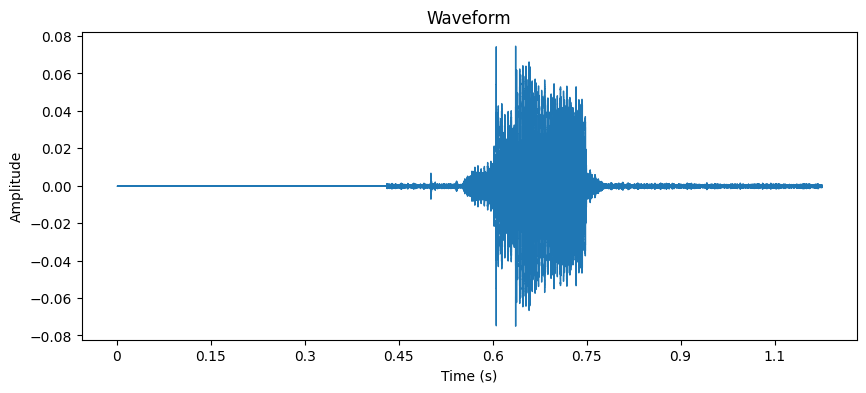

In [15]:
plot_waveform(audio_data, sr)

Before training a machine learning model, the raw audio array with sampled amplitudes must be transformed. Transforming this raw signal into mel spectrograms enables the machine learning model to learn speech-relevant acoustic patterns more efficiently. The transformation reorganizes the signal into a structured time-by-frequency map that highlights speech patterns like vowels and consonants.

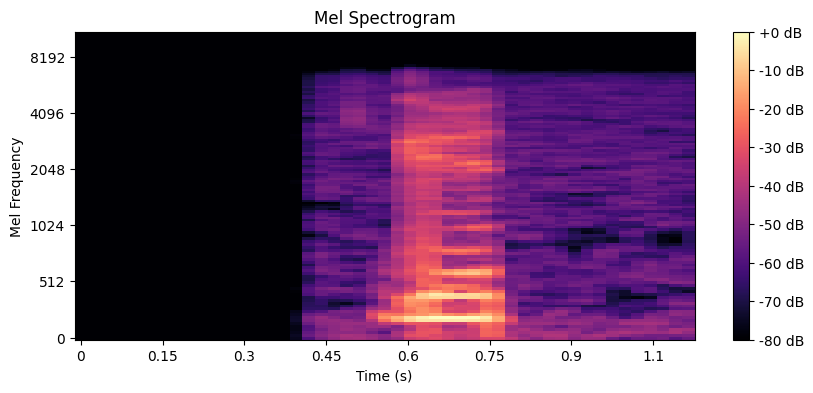

In [16]:
plot_melspectrogram(audio_data, sr)

When training machine learning models, this transformation is often handled under-the-hood by processors or feature extractors. For example, in our benchmark model implementation, we will fine tune NVIDIA’s pretrained `parakeet-tdt-0.6b-v2` model using [NeMo](https://docs.nvidia.com/nemo-framework/user-guide/24.09/index.html). NeMo's architecture includes a built-in preprocessing pipeline that converts raw audio waveforms into mel-spectrogram features, eliminating the need for manual feature extraction.

For more tips on generating predictive features from audio data, check out DrivenData's [overview](https://drivendata.co/blog/speech-for-ml) of open-source packages for using speech data in ML. That blog post also includes some helpful intro to working with audio data.

___
# Step 2: Build the model

A straightforward modeling option is to start from a strong pretrained ASR model (trained mostly on adult speech), then fine-tune on our labeled child-speech training set. Fine-tuning the ASR model will help it understand the unique acoustic and linguistic patterns of children. Before choosing a pre-trained model, make sure it adheres to the [competition rules](https://www.drivendata.org/competitions/308/childrens-word-asr/#external-data-and-models).

In this tutorial, we adapt NVIDIA’s pretrained Parakeet TDT `parakeet-tdt-0.6b-v2` model using NeMo. We chose this model because it is open source, ranks highly on the Hugging Face [Open ASR leaderboard](https://huggingface.co/spaces/hf-audio/open_asr_leaderboard) (at time of writing), and strikes a good balance between performance and model size. Rather than fine-tuning all parameters, we will freeze the base model and train only lightweight adapter weights. **Adapters** are small, trainable modules inserted into the frozen model’s layers that allow it to adapt to new data without modifying the original pretrained weights. Freezing the base model makes the fine-tuning process more efficient and helps avoid overfitting. NeMo makes this process easier by providing native adapter support, handling data pipelines (manifests, batching, feature extraction), and integrating experiment management (checkpointing, logging).

Key packages include: 
 * `nemo_toolkit` for ASR model + data processing
 * `lightning.pytorch` for the training backend
 * `omegaconf` for config file management

## 1. Prepare Dataset & Create Splits

We need to provide NeMo with a "manifest" JSONL file that lists all of our samples and sample information. NeMo requires this manifest to be in a particular format, with specific column names and definitions. Each manifest line must be a JSON object with `audio_filepath` (path to audio file), `duration` (audio duration in seconds), and `text` (transcription text).

Below we will transform the competition data to NeMo's required manifest format. 

We'll also filter out clips longer than 25 seconds, which strain computer memory. Competitors may want to further split these clips to avoid losing training data. Then we'll split the data 80/20 into train/validation.

In [17]:
MANIFEST_DIR = DATA_ROOT / "processed" / "ortho_dataset"
train_manifest_path = MANIFEST_DIR / "train_manifest.jsonl"
val_manifest_path = MANIFEST_DIR / "val_manifest.jsonl"
clip_max_duration_sec = 25.0

MANIFEST_DIR.mkdir(parents=True, exist_ok=True)

Remember, `df` has one row per utterance, and includes data hosted on both TalkBank and DrivenData.

In [18]:
df = df[["audio_path", "audio_duration_sec", "orthographic_text"]].rename(
    columns={
        "audio_path": "audio_filepath",
        "audio_duration_sec": "duration",
        "orthographic_text": "text",
    }
)

# Removing long clips to improve memory efficiency during training
over_max_duration_mask = df["duration"] > clip_max_duration_sec
logger.info(
    f"Removing {over_max_duration_mask.sum()} samples with audio duration "
    f"> {clip_max_duration_sec} seconds"
)
df = df[~over_max_duration_mask]

if SAMPLE:
    logger.info(f"Sampling {SAMPLE} utterances")
    df = df.sample(SAMPLE, random_state=10)

train_df, val_df = train_test_split(df, test_size=0.2, random_state=10)

train_df.to_json(train_manifest_path, orient="records", lines=True)
val_df.to_json(val_manifest_path, orient="records", lines=True)

2026-03-23 16:15:21.159 | INFO     | __main__:<module>:11 - Removing 3849 samples with audio duration > 25.0 seconds


## 2. Configuration

Let's define parameters for the adaptation. 
 - To start, we copied an example .yaml file for ASR adaptation using NeMo from the [NeMo repository](https://github.com/NVIDIA-NeMo/NeMo/blob/main/examples/asr/conf/asr_adapters/asr_adaptation.yaml) to `asr_benchmark/assets/asr_adaptation.yaml`. This file gives us a reasonable default starting-point configuration.
 - We want to overtly set some parameters, like:
   - `pretrained_model` (to specify `parakeet-tdt-0.6b-v2`)
   - `manifest_filepath` (to point to our manifest locations)
   - `channel_selector` (to ensure audio is converted to the expected mono format if it is stereo in raw form)
   - `max_steps` (to control how many training steps we complete before we stop training)
 - For these parameters, we override the default settings in the .yaml using `OmegaConf.merge`.
 - While we do not implement hyperparameter tuning here, it is recommended for competitors.

In [19]:
# ── Hardware-dependent settings ──────────────────────────────────────────────
# Adjust these to match your GPU memory and CPU cores.
DEVICES = 1
PRECISION = "bf16-mixed"
BATCH_SIZE = 8
NUM_WORKERS = 8

# ── Load NeMo adapter defaults ───────────────────────────────────────────────
yaml_path = PROJECT_ROOT / "asr_benchmark" / "assets" / "asr_adaptation.yaml"
cfg = OmegaConf.load(yaml_path)

# ── Training overrides ───────────────────────────────────────────────────────
overrides = OmegaConf.create(
    {
        "model": {
            "pretrained_model": "nvidia/parakeet-tdt-0.6b-v2",
            "adapter": {
                "adapter_name": "asr_children_orthographic",
                "adapter_module_name": "encoder",
                "linear": {"in_features": 1024},
            },
            "train_ds": {
                "manifest_filepath": str(train_manifest_path),
                "batch_size": BATCH_SIZE,
                "num_workers": NUM_WORKERS,
                "use_lhotse": False,
                "channel_selector": "average",
            },
            "validation_ds": {
                "manifest_filepath": str(val_manifest_path),
                "batch_size": BATCH_SIZE,
                "num_workers": NUM_WORKERS,
                "use_lhotse": False,
                "channel_selector": "average",
            },
            "optim": {
                "lr": 0.001,
                "weight_decay": 0.0,
            },
        },
        "trainer": {
            "devices": DEVICES,
            "precision": PRECISION,
            "strategy": "auto",
            "max_epochs": 1 if SAMPLE else None,
            "max_steps": -1 if SAMPLE else 5000,
            "val_check_interval": 1.0 if SAMPLE else 500,
            "enable_progress_bar": False,
        },
        "exp_manager": {
            "exp_dir": str(PROJECT_ROOT / "models" / "orthographic_benchmark_nemo"),
        },
    }
)

cfg = OmegaConf.merge(cfg, overrides)

## 3. Define Trainer

The Trainer orchestrates the training loop across devices, delegating tensor operations to PyTorch's backend. We initiate the trainer with the `OmegaConf` config object we made above, and then set up an experiment manager to handle logging, checkpoint saving, and saving artifacts to disk.

Note we use the cell magic [`%%capture`](https://ipython.readthedocs.io/en/9.2.0/interactive/magics.html#cellmagic-capture) below to hide long cell outputs for readability.

In [20]:
%%capture
trainer = pl.Trainer(**resolve_trainer_cfg(cfg.trainer))
exp_log_dir = exp_manager(trainer, cfg.get("exp_manager", None))

Using bfloat16 Automatic Mixed Precision (AMP)
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


[NeMo I 2026-03-23 16:15:27 nemo_logging:393] ExpManager schema
[NeMo I 2026-03-23 16:15:27 nemo_logging:393] {'explicit_log_dir': None, 'exp_dir': None, 'name': None, 'version': None, 'use_datetime_version': True, 'resume_if_exists': False, 'resume_past_end': False, 'resume_ignore_no_checkpoint': False, 'resume_from_checkpoint': None, 'create_tensorboard_logger': True, 'summary_writer_kwargs': None, 'create_wandb_logger': False, 'wandb_logger_kwargs': None, 'create_mlflow_logger': False, 'mlflow_logger_kwargs': {'experiment_name': None, 'run_name': None, 'tracking_uri': None, 'tags': None, 'save_dir': './mlruns', 'prefix': '', 'artifact_location': None, 'run_id': None, 'log_model': False}, 'create_dllogger_logger': False, 'dllogger_logger_kwargs': {'verbose': False, 'stdout': False, 'json_file': './dllogger.json'}, 'create_clearml_logger': False, 'clearml_logger_kwargs': {'project': None, 'task': None, 'connect_pytorch': False, 'model_name': None, 'tags': None, 'log_model': False, 'lo

[NeMo W 2026-03-23 16:15:27 nemo_logging:405] The checkpoint callback was told to monitor a validation value and trainer's max_steps was set to 5000. Please ensure that max_steps will run for at least 1 epochs to ensure that checkpointing will not error out.


[NeMo I 2026-03-23 16:15:27 nemo_logging:393] TFLOPs per sec per GPU will be calculated, conditioned on supported models. Defaults to -1 upon failure.


## 4. Data and Model Setup

We load the pretrained model by fetching the model from our config first and then patching it for adapter support. Then, we load the model weights.

In [21]:
%%capture
model_cfg = ASRModel.from_pretrained(cfg.model.pretrained_model, return_config=True)
update_model_config_to_support_adapter(model_cfg, cfg)
model = ASRModel.from_pretrained(
    cfg.model.pretrained_model,
    override_config_path=model_cfg,
    trainer=trainer,
)

[NeMo I 2026-03-23 16:15:32 nemo_logging:393] Tokenizer SentencePieceTokenizer initialized with 1024 tokens


[NeMo W 2026-03-23 16:15:32 nemo_logging:405] If you intend to do training or fine-tuning, please call the ModelPT.setup_training_data() method and provide a valid configuration file to setup the train data loader.
    Train config : 
    use_lhotse: true
    skip_missing_manifest_entries: true
    input_cfg: null
    tarred_audio_filepaths: null
    manifest_filepath: null
    sample_rate: 16000
    shuffle: true
    num_workers: 2
    pin_memory: true
    max_duration: 40.0
    min_duration: 0.1
    text_field: answer
    batch_duration: null
    use_bucketing: true
    bucket_duration_bins: null
    bucket_batch_size: null
    num_buckets: 30
    bucket_buffer_size: 20000
    shuffle_buffer_size: 10000
    
[NeMo W 2026-03-23 16:15:32 nemo_logging:405] If you intend to do validation, please call the ModelPT.setup_validation_data() or ModelPT.setup_multiple_validation_data() method and provide a valid configuration file to setup the validation data loader(s). 
    Validation config :

[NeMo I 2026-03-23 16:15:32 nemo_logging:393] PADDING: 0
[NeMo I 2026-03-23 16:15:35 nemo_logging:393] Using RNNT Loss : tdt
    Loss tdt_kwargs: {'fastemit_lambda': 0.0, 'clamp': -1.0, 'durations': [0, 1, 2, 3, 4], 'sigma': 0.02, 'omega': 0.1}
[NeMo I 2026-03-23 16:15:35 nemo_logging:393] Using RNNT Loss : tdt
    Loss tdt_kwargs: {'fastemit_lambda': 0.0, 'clamp': -1.0, 'durations': [0, 1, 2, 3, 4], 'sigma': 0.02, 'omega': 0.1}
[NeMo I 2026-03-23 16:15:35 nemo_logging:393] Using RNNT Loss : tdt
    Loss tdt_kwargs: {'fastemit_lambda': 0.0, 'clamp': -1.0, 'durations': [0, 1, 2, 3, 4], 'sigma': 0.02, 'omega': 0.1}
[NeMo I 2026-03-23 16:15:36 nemo_logging:393] Model EncDecRNNTBPEModel was successfully restored from /home/bikki2/.cache/huggingface/hub/models--nvidia--parakeet-tdt-0.6b-v2/snapshots/48b630d20b000e5ad3735e5378a2d9bde3f80826/parakeet-tdt-0.6b-v2.nemo.


We disable the CUDA graph decoder because it is incompatible with current PyTorch (2.10).

In [22]:
%%capture
with open_dict(model.cfg):
    model.cfg.decoding.greedy.use_cuda_graph_decoder = False
model.change_decoding_strategy(model.cfg.decoding)

[NeMo I 2026-03-23 16:15:36 nemo_logging:393] Using RNNT Loss : tdt
    Loss tdt_kwargs: {'fastemit_lambda': 0.0, 'clamp': -1.0, 'durations': [0, 1, 2, 3, 4], 'sigma': 0.02, 'omega': 0.1}
[NeMo I 2026-03-23 16:15:36 nemo_logging:393] Changed decoding strategy to 
    model_type: tdt
    strategy: greedy_batch
    compute_hypothesis_token_set: false
    preserve_alignments: null
    tdt_include_token_duration: null
    confidence_cfg:
      preserve_frame_confidence: false
      preserve_token_confidence: false
      preserve_word_confidence: false
      exclude_blank: true
      aggregation: min
      tdt_include_duration: false
      method_cfg:
        name: entropy
        entropy_type: tsallis
        alpha: 0.33
        entropy_norm: exp
        temperature: DEPRECATED
    fused_batch_size: null
    compute_timestamps: null
    compute_langs: false
    word_seperator: ' '
    segment_seperators:
    - .
    - '!'
    - '?'
    segment_gap_threshold: null
    rnnt_timestamp_type: a

Next, we prepare our data by merging our parameter overrides (batch size, num workers, etc.) into the model's built-in data config. Note that while keys not present in the original config are dropped, whitelisted keys are always injected.

In [23]:
cfg.model.train_ds = update_model_cfg(model.cfg.train_ds, cfg.model.train_ds)
model.setup_training_data(cfg.model.train_ds)

cfg.model.validation_ds = update_model_cfg(model.cfg.validation_ds, cfg.model.validation_ds)
model.setup_multiple_validation_data(cfg.model.validation_ds)

Injecting white listed key `num_workers` into config
Injecting white listed key `pin_memory` into config
Injecting white listed key `batch_size` into config
Injecting white listed key `use_lhotse` into config
Injecting white listed key `channel_selector` into config
Removing unavailable key from config : is_tarred
Removing unavailable key from config : shuffle_n
Removing unavailable key from config : bucketing_strategy
Removing unavailable key from config : bucketing_batch_size
[NeMo I 2026-03-23 16:15:40 nemo_logging:393] Dataset loaded with 277410 files totalling 244.57 hours
[NeMo I 2026-03-23 16:15:40 nemo_logging:393] 5 files were filtered totalling 0.00 hours
Injecting white listed key `num_workers` into config
Injecting white listed key `pin_memory` into config
Injecting white listed key `batch_size` into config
Injecting white listed key `use_lhotse` into config
Injecting white listed key `channel_selector` into config
[NeMo I 2026-03-23 16:15:41 nemo_logging:393] Dataset loade

We also need to set the optimization function, which controls how the model’s weights are updated using gradients to minimize the loss and improve performance during training. We use AdamW with cosine annealing schedule and 10% warmup ratio as a starting point.

In [24]:
%%capture
model.setup_optimization(cfg.model.optim)

[NeMo I 2026-03-23 16:15:41 nemo_logging:393] Optimizer config = AdamW (
    Parameter Group 0
        amsgrad: False
        betas: (0.9, 0.98)
        capturable: False
        decoupled_weight_decay: True
        differentiable: False
        eps: 1e-08
        foreach: None
        fused: None
        lr: 0.001
        maximize: False
        weight_decay: 0.0
    )
[NeMo I 2026-03-23 16:15:41 nemo_logging:393] Scheduler "<nemo.core.optim.lr_scheduler.CosineAnnealing object at 0x7e55e6e92d90>" 
    will be used during training (effective maximum steps = 5000) - 
    Parameters : 
    (warmup_steps: null
    warmup_ratio: 0.1
    min_lr: 1.0e-05
    last_epoch: -1
    max_steps: 5000
    )


In [25]:
# Configure spec augmentation from config if available, otherwise disable it.
if "spec_augment" in cfg.model:
    model.spec_augmentation = model.from_config_dict(cfg.model.spec_augment)
else:
    model.spec_augmentation = None
    del model.cfg.spec_augment

## 5. Set up Adapter

An adapter is a small neural network module that learns to transform the pretrained model's internal representations specifically for child speech. Rather than retraining the entire model, we insert lightweight adapters into each layer of the encoder, the part of the model that processes audio features.

We add a linear adapter to every encoder layer, then freeze the base model and unfreeze only the adapter weights. This keeps training efficient—only ~0.1% of parameters are trainable, while (hopefully) allowing the adapter to learn the acoustic and linguistic patterns unique to children's voices.

In [26]:
%%capture
with open_dict(cfg.model.adapter):
    adapter_name = cfg.model.adapter.pop("adapter_name")
    adapter_type = cfg.model.adapter.pop("adapter_type")
    adapter_module_name = cfg.model.adapter.pop("adapter_module_name", None)
    adapter_state_dict_name = cfg.model.adapter.pop("adapter_state_dict_name", None)

    adapter_type_cfg = cfg.model.adapter[adapter_type]

    if adapter_module_name is not None and ":" not in adapter_name:
        adapter_name = f"{adapter_module_name}:{adapter_name}"

    adapter_global_cfg = cfg.model.adapter.pop(model.adapter_global_cfg_key, None)
    if adapter_global_cfg is not None:
        add_global_adapter_cfg(model, adapter_global_cfg)

model.add_adapter(adapter_name, cfg=adapter_type_cfg)
assert model.is_adapter_available()

model.set_enabled_adapters(enabled=False)
model.set_enabled_adapters(adapter_name, enabled=True)

model.freeze()
model = model.train()
model.unfreeze_enabled_adapters()

[NeMo I 2026-03-23 16:15:47 nemo_logging:393] Setting adapter 'asr_children_orthographic' status : Enabled = False
[NeMo I 2026-03-23 16:15:47 nemo_logging:393] Setting adapter 'encoder:asr_children_orthographic' status : Enabled = True
[NeMo I 2026-03-23 16:15:47 nemo_logging:393] Froze module encoder.layers.0.conv.batch_norm: BatchNorm1d(1024, eps=1e-05, momentum=0.1, affine=True, track_running_stats=False)
[NeMo I 2026-03-23 16:15:47 nemo_logging:393] Froze module encoder.layers.1.conv.batch_norm: BatchNorm1d(1024, eps=1e-05, momentum=0.1, affine=True, track_running_stats=False)
[NeMo I 2026-03-23 16:15:47 nemo_logging:393] Froze module encoder.layers.2.conv.batch_norm: BatchNorm1d(1024, eps=1e-05, momentum=0.1, affine=True, track_running_stats=False)
[NeMo I 2026-03-23 16:15:47 nemo_logging:393] Froze module encoder.layers.3.conv.batch_norm: BatchNorm1d(1024, eps=1e-05, momentum=0.1, affine=True, track_running_stats=False)
[NeMo I 2026-03-23 16:15:47 nemo_logging:393] Froze module 

In [27]:
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total parameters:     {total_params:,}")
print(f"Trainable parameters: {trainable_params:,} ({100 * trainable_params / total_params:.2f}%)")

Total parameters:     619,447,942
Trainable parameters: 1,622,016 (0.26%)


## 6. Train

Let's adapt the pretrained model to children's voices!

In [28]:
import os
import torch
from numba import cuda

# 1. Check PyTorch GPU access
print(f"PyTorch CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"PyTorch Device: {torch.cuda.get_device_name(0)}")

# 2. Check Numba (NVVM) access
print(f"\nNumba CUDA available: {cuda.is_available()}")
try:
    cuda.detect()
except Exception as e:
    print(f"Numba Error: {e}")

# 3. Verify Environment Variables
print(f"\nCUDA_HOME: {os.environ.get('CUDA_HOME')}")
print(f"LD_LIBRARY_PATH: {os.environ.get('LD_LIBRARY_PATH')}")

PyTorch CUDA available: True
PyTorch Device: NVIDIA GeForce RTX 4070

Numba CUDA available: True
Found 1 CUDA devices
id 0    NVIDIA GeForce RTX 4070                                                                                                                                       [SUPPORTED]
                      Compute Capability: 8.9
                           PCI Device ID: 0
                              PCI Bus ID: 1
                                    UUID: GPU-7d424585-2447-1535-26ce-b5f72dce693e
                                Watchdog: Enabled
             FP32/FP64 Performance Ratio: 64
Summary:
	1/1 devices are supported

CUDA_HOME: /usr/local/cuda
LD_LIBRARY_PATH: /usr/local/cuda/lib64:/usr/local/cuda/nvvm/lib64:


In [29]:
%%capture
trainer.fit(model)

LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


[NeMo I 2026-03-23 16:18:33 nemo_logging:393] Optimizer config = AdamW (
    Parameter Group 0
        amsgrad: False
        betas: (0.9, 0.98)
        capturable: False
        decoupled_weight_decay: True
        differentiable: False
        eps: 1e-08
        foreach: None
        fused: None
        lr: 0.001
        maximize: False
        weight_decay: 0.0
    )
[NeMo I 2026-03-23 16:18:33 nemo_logging:393] Scheduler "<nemo.core.optim.lr_scheduler.CosineAnnealing object at 0x7e5598063750>" 
    will be used during training (effective maximum steps = 5000) - 
    Parameters : 
    (warmup_steps: null
    warmup_ratio: 0.1
    min_lr: 1.0e-05
    last_epoch: -1
    max_steps: 5000
    )



  | Name              | Type                              | Params | Mode 
--------------------------------------------------------------------------------
0 | preprocessor      | AudioToMelSpectrogramPreprocessor | 0      | train
1 | encoder           | ConformerEncoderAdapter           | 610 M  | train
2 | decoder           | RNNTDecoder                       | 7.2 M  | train
3 | joint             | RNNTJoint                         | 1.7 M  | train
4 | loss              | RNNTLoss                          | 0      | train
5 | spec_augmentation | SpectrogramAugmentation           | 0      | train
6 | wer               | WER                               | 0      | train
--------------------------------------------------------------------------------
1.6 M     Trainable params
617 M     Non-trainable params
619 M     Total params
2,477.792 Total estimated model params size (MB)
849       Modules in train mode
24        Modules in eval mode


[NeMo I 2026-03-23 16:18:33 nemo_logging:393] Preemption requires torch distributed to be initialized, disabling preemption


[NeMo W 2026-03-23 16:18:34 nemo_logging:405] No adapter compatible with the current module. Skipping adapter forward pass.
[NeMo W 2026-03-23 16:18:35 nemo_logging:405] /home/bikki2/projects/childrens-speech-recognition-benchmark-pub/.venv/lib/python3.11/site-packages/numba_cuda/numba/cuda/dispatcher.py:685: NumbaPerformanceWarning: Grid size 4 will likely result in GPU under-utilization due to low occupancy.
      warn(NumbaPerformanceWarning(msg))
    
[NeMo W 2026-03-23 16:18:36 nemo_logging:405] /home/bikki2/projects/childrens-speech-recognition-benchmark-pub/.venv/lib/python3.11/site-packages/numba_cuda/numba/cuda/dispatcher.py:685: NumbaPerformanceWarning: Grid size 4 will likely result in GPU under-utilization due to low occupancy.
      warn(NumbaPerformanceWarning(msg))
    
[NeMo W 2026-03-23 16:18:37 nemo_logging:405] /home/bikki2/projects/childrens-speech-recognition-benchmark-pub/.venv/lib/python3.11/site-packages/numba_cuda/numba/cuda/dispatcher.py:685: NumbaPerformanceW

...

[NeMo I 2026-03-23 19:26:16 nemo_logging:393] Checkpoint save for step 4500 started at 1774293976.8401384.
[NeMo I 2026-03-23 19:26:16 nemo_logging:393] /home/bikki2/projects/childrens-speech-recognition-benchmark-pub/models/orthographic_benchmark_nemo/ASR-Adapter/2026-03-23_16-15-27/checkpoints/ASR-Adapter.nemo already exists, moving existing checkpoint to /home/bikki2/projects/childrens-speech-recognition-benchmark-pub/models/orthographic_benchmark_nemo/ASR-Adapter/2026-03-23_16-15-27/checkpoints/ASR-Adapter-v1.nemo
[NeMo I 2026-03-23 19:26:19 nemo_logging:393] New .nemo model saved to: /home/bikki2/projects/childrens-speech-recognition-benchmark-pub/models/orthographic_benchmark_nemo/ASR-Adapter/2026-03-23_16-15-27/checkpoints/ASR-Adapter.nemo
[NeMo I 2026-03-23 19:26:19 nemo_logging:393] Removing old .nemo backup /home/bikki2/projects/childrens-speech-recognition-benchmark-pub/models/orthographic_benchmark_nemo/ASR-Adapter/2026-03-23_16-15-27/checkpoints/ASR-Adapter-v1.nemo
[NeMo I

Epoch 0, global step 5000: 'val_wer' reached 0.17601 (best 0.17598), saving model to '/home/bikki2/projects/childrens-speech-recognition-benchmark-pub/models/orthographic_benchmark_nemo/ASR-Adapter/2026-03-23_16-15-27/checkpoints/ASR-Adapter--val_wer=0.1760-epoch=0-v1.ckpt' as top 5


[NeMo I 2026-03-23 19:47:46 nemo_logging:393] Checkpoint save for step 5000 started at 1774295266.7584233.
[NeMo I 2026-03-23 19:47:46 nemo_logging:393] /home/bikki2/projects/childrens-speech-recognition-benchmark-pub/models/orthographic_benchmark_nemo/ASR-Adapter/2026-03-23_16-15-27/checkpoints/ASR-Adapter.nemo already exists, moving existing checkpoint to /home/bikki2/projects/childrens-speech-recognition-benchmark-pub/models/orthographic_benchmark_nemo/ASR-Adapter/2026-03-23_16-15-27/checkpoints/ASR-Adapter-v1.nemo
[NeMo I 2026-03-23 19:47:49 nemo_logging:393] New .nemo model saved to: /home/bikki2/projects/childrens-speech-recognition-benchmark-pub/models/orthographic_benchmark_nemo/ASR-Adapter/2026-03-23_16-15-27/checkpoints/ASR-Adapter.nemo
[NeMo I 2026-03-23 19:47:49 nemo_logging:393] Removing old .nemo backup /home/bikki2/projects/childrens-speech-recognition-benchmark-pub/models/orthographic_benchmark_nemo/ASR-Adapter/2026-03-23_16-15-27/checkpoints/ASR-Adapter-v1.nemo
[NeMo I

`Trainer.fit` stopped: `max_steps=5000` reached.


[NeMo I 2026-03-23 19:47:58 nemo_logging:393] /home/bikki2/projects/childrens-speech-recognition-benchmark-pub/models/orthographic_benchmark_nemo/ASR-Adapter/2026-03-23_16-15-27/checkpoints/ASR-Adapter.nemo already exists, moving existing checkpoint to /home/bikki2/projects/childrens-speech-recognition-benchmark-pub/models/orthographic_benchmark_nemo/ASR-Adapter/2026-03-23_16-15-27/checkpoints/ASR-Adapter-v1.nemo
[NeMo I 2026-03-23 19:48:02 nemo_logging:393] Removing old .nemo backup /home/bikki2/projects/childrens-speech-recognition-benchmark-pub/models/orthographic_benchmark_nemo/ASR-Adapter/2026-03-23_16-15-27/checkpoints/ASR-Adapter-v1.nemo


We've hidden the training cell outputs to avoid printing many lines of logs. Below are a few key snippets of the log output that we saw when training:
```bash
  | Name              | Type                              | Params | Mode 
--------------------------------------------------------------------------------
0 | preprocessor      | AudioToMelSpectrogramPreprocessor | 0      | train
1 | encoder           | ConformerEncoderAdapter           | 610 M  | train
2 | decoder           | RNNTDecoder                       | 7.2 M  | train
3 | joint             | RNNTJoint                         | 1.7 M  | train
4 | loss              | RNNTLoss                          | 0      | train
5 | spec_augmentation | SpectrogramAugmentation           | 0      | train
6 | wer               | WER                               | 0      | train
--------------------------------------------------------------------------------
1.6 M     Trainable params
617 M     Non-trainable params
619 M     Total params
2,477.792 Total estimated model params size (MB)

Epoch 0, global step 500: 'val_wer' reached 0.20008 (best 0.20008), saving model to '/models/orthographic_benchmark_nemo/ASR-Adapter/2026-02-26_04-58-33/checkpoints/ASR-Adapter--val_wer=0.2001-epoch=0.ckpt' as top 5
...
Epoch 0, global step 5000: 'val_wer' reached 0.16359 (best 0.16359), saving model to '/models/orthographic_benchmark_nemo/ASR-Adapter/2026-02-26_04-58-33/checkpoints/ASR-Adapter--val_wer=0.1636-epoch=0.ckpt' as top 5
`Trainer.fit` stopped: `max_steps=5000` reached.
```

Because we configured `max_steps` to be 5,000, we stopped training before we completed the first epoch.

We need to save the final results. We save the adapter weights to a standalone file alongside the NeMo checkpoints.

In [30]:
if adapter_state_dict_name is not None:
    state_path = exp_log_dir if exp_log_dir is not None else os.getcwd()
    ckpt_path = os.path.join(state_path, "checkpoints")
    if os.path.exists(ckpt_path):
        state_path = ckpt_path
    state_path = os.path.join(state_path, adapter_state_dict_name)

    model.save_adapters(str(state_path))

In [31]:
# Returns the absolute path to the best .ckpt or .nemo file
print(f"Best model path: {trainer.checkpoint_callback.best_model_path}")

# Returns the current logging directory
print(f"Log directory: {trainer.log_dir}")

Best model path: /home/bikki2/projects/childrens-speech-recognition-benchmark-pub/models/orthographic_benchmark_nemo/ASR-Adapter/2026-03-23_16-15-27/checkpoints/ASR-Adapter--val_wer=0.1760-epoch=0.ckpt
Log directory: /home/bikki2/projects/childrens-speech-recognition-benchmark-pub/models/orthographic_benchmark_nemo/ASR-Adapter/2026-03-23_16-15-27


## 

## 7. Evaluation
Now it's time to assess how well our adapted model performs. We load the best trained checkpoint from disk and run inference across the entire validation set. The model transcribes each audio clip, and we compare these predictions against the reference transcriptions using Word Error Rate (WER). The WER calculation is copied exactly from the [runtime repository](https://github.com/drivendataorg/childrens-speech-recognition-runtime/blob/main/metric/score.py).

In [32]:
%%capture
nemo_ckpts = sorted((exp_log_dir / "checkpoints").glob("*.nemo"))
if not nemo_ckpts:
    raise FileNotFoundError(f"No .nemo checkpoints found in {exp_log_dir}/checkpoints/")

best_ckpt = nemo_ckpts[-1]
print(f"Loading checkpoint: {best_ckpt}")
eval_model = ASRModel.restore_from(best_ckpt, map_location="cuda")

with open_dict(eval_model.cfg):
    eval_model.cfg.decoding.greedy.use_cuda_graph_decoder = False
eval_model.change_decoding_strategy(eval_model.cfg.decoding)

patch_transcribe_lhotse(eval_model)

[NeMo I 2026-03-23 19:54:43 nemo_logging:393] Tokenizer SentencePieceTokenizer initialized with 1024 tokens


[NeMo W 2026-03-23 19:54:43 nemo_logging:405] If you intend to do training or fine-tuning, please call the ModelPT.setup_training_data() method and provide a valid configuration file to setup the train data loader.
    Train config : 
    use_lhotse: false
    skip_missing_manifest_entries: true
    input_cfg: null
    tarred_audio_filepaths: null
    manifest_filepath: /home/bikki2/projects/childrens-speech-recognition-benchmark-pub/data/processed/ortho_dataset/train_manifest.jsonl
    sample_rate: 16000
    shuffle: true
    num_workers: 8
    pin_memory: true
    max_duration: 40.0
    min_duration: 0.1
    text_field: answer
    batch_duration: null
    use_bucketing: true
    bucket_duration_bins: null
    bucket_batch_size: null
    num_buckets: 30
    bucket_buffer_size: 20000
    shuffle_buffer_size: 10000
    batch_size: 8
    channel_selector: average
    
[NeMo W 2026-03-23 19:54:43 nemo_logging:405] If you intend to do validation, please call the ModelPT.setup_validation_da

[NeMo I 2026-03-23 19:54:43 nemo_logging:393] PADDING: 0
[NeMo I 2026-03-23 19:54:45 nemo_logging:393] Using RNNT Loss : tdt
    Loss tdt_kwargs: {'fastemit_lambda': 0.0, 'clamp': -1.0, 'durations': [0, 1, 2, 3, 4], 'sigma': 0.02, 'omega': 0.1}
[NeMo I 2026-03-23 19:54:45 nemo_logging:393] Using RNNT Loss : tdt
    Loss tdt_kwargs: {'fastemit_lambda': 0.0, 'clamp': -1.0, 'durations': [0, 1, 2, 3, 4], 'sigma': 0.02, 'omega': 0.1}
[NeMo I 2026-03-23 19:54:45 nemo_logging:393] Finished setup of adapter : 'encoder:asr_children_orthographic'. Enabled: True.
[NeMo I 2026-03-23 19:54:45 nemo_logging:393] Using RNNT Loss : tdt
    Loss tdt_kwargs: {'fastemit_lambda': 0.0, 'clamp': -1.0, 'durations': [0, 1, 2, 3, 4], 'sigma': 0.02, 'omega': 0.1}
[NeMo I 2026-03-23 19:54:47 nemo_logging:393] Model EncDecRNNTBPEModel was successfully restored from /home/bikki2/projects/childrens-speech-recognition-benchmark-pub/models/orthographic_benchmark_nemo/ASR-Adapter/2026-03-23_16-15-27/checkpoints/ASR-Ada

In [33]:
val_manifest_path = cfg.model.validation_ds.manifest_filepath
with open(val_manifest_path) as f:
    val_entries = [json.loads(line) for line in f]

audio_files = [e["audio_filepath"] for e in val_entries]
references = [e["text"] for e in val_entries]

print(f"Running inference on {len(audio_files)} validation utterances...")
raw = eval_model.transcribe(
    audio_files, batch_size=BATCH_SIZE, channel_selector="average", verbose=False
)
if isinstance(raw, tuple):
    raw = raw[0]

predictions = [h.text if hasattr(h, "text") else h for h in raw]

Running inference on 69354 validation utterances...


Before scoring, let's remove any example where the normalized label is an empty string.

In [34]:
normalizer = EnglishTextNormalizer(english_spelling_normalizer)
filtered = [(r, p) for r, p in zip(references, predictions) if normalizer(r) != ""]

references, predictions = zip(*filtered)

wer = score_wer(references, predictions)

print(f"Validation WER: {wer:.4f}")

print("\nSample predictions:")
for ref, pred in zip(references[:5], predictions[:5]):
    print(f"  REF:  {ref}")
    print(f"  PRED: {pred}")
    print()

Validation WER: 0.1654

Sample predictions:
  REF:  ar
  PRED: ar

  REF:  they were going on a walk to a picnic
  PRED: they were going on a walk to a picnic

  REF:  a deer is little
  PRED: a damn

  REF:  what's happening is when you when there's an op when there's a closed circuit the there is a the post but the wire's wrapped around it is carrying some washers and when it
  PRED: what's happening is when you when there's an o when there's a closed circuit the there is a the post with the wires wrapped around it is carrying some washers and when it

  REF:  blue
  PRED: blue



Our Validation WER after adapting the model is 0.15! 

___
# Step 3: Make your submission

Since this is a code execution competition, we will submit our model weights and code rather than predictions. See the [code submission format](https://www.drivendata.org/competitions/308/childrens-word-asr/page/978/) webpage for more information.

The general steps to follow:

1. Develop inference code
2. Test your submission locally
3. Package submission
4. Make a smoke test submission
5. Once you have successfully debugged your submission, submit it for scoring on the full test set!


## Develop Inference Code

We need to set up a repository with a `main.py` Python script which performs inference in the [competition execution environment](https://github.com/drivendataorg/childrens-speech-recognition-runtime/tree/main) and writes our predictions to the required output file.  During code execution, our submission will be unzipped and run in the cloud compute cluster. The container will run your `main.py` script.

Our code must write a JSON Lines (JSONL) file containing one prediction per utterance.

Each line must include:
- `utterance_id`
- `orthographic_text`: UTF-8, standard English transcription of the utterance
The submission should be written to ./submission/submission.jsonl relative to the working directory.

See more details in the [code submission format](https://www.drivendata.org/competitions/308/childrens-word-asr/page/978/) webpage and in the [example submission](https://github.com/drivendataorg/childrens-speech-recognition-runtime/tree/main/examples/word/parakeet). 

In our `main.py`, we load the trained adapter checkpoint from disk, restore the NeMo model, and run inference on all test utterances in batches. The script reads audio file paths from the test manifest, transcribes them using the adapted model, and writes the predicted transcriptions to the submission file in the required format. We sort utterances by duration before inference (longest first) to improve GPU memory efficiency during batching.

See `orthographic_submission/main.py` for the details.

This repository provides a useful justfile command to run the trained model on a few sample files.

```bash
# Run inference using data-demo/word/ to test orthographic submission
test-orthographic:
    uv run orthographic_submission/main.py models/orthographic_benchmark_nemo/ASR-Adapter-best.nemo data-demo/word/utterance_metadata.jsonl
```

## Package Submission

Now we will package up our model and inference code into a zip file for predicting on the test set in the runtime container. This repository provides a justfile command to do this. The justfile finds the latest models weights, and then creates a zipfile combining those model weights with `/orthographic_submissions/main.py`.

```bash
pack-orthographic:
    #!/usr/bin/env bash
    set -euo pipefail
    latest=$(ls -td models/orthographic_benchmark_nemo/ASR-Adapter/*/checkpoints/ASR-Adapter.nemo | head -1)
    ln -sf "${latest#models/orthographic_benchmark_nemo/}" models/orthographic_benchmark_nemo/ASR-Adapter-best.nemo
    echo "Updated ASR-Adapter-best.nemo -> $latest"
    rm -f orthographic_submission.zip
    (cd orthographic_submission && zip -r ../orthographic_submission.zip main.py)
    (cd models/orthographic_benchmark_nemo && zip -r ../../orthographic_submission.zip ASR-Adapter-best.nemo)
```

Another packing command is available on the runtime repo's orthographic [example](https://github.com/drivendataorg/childrens-speech-recognition-runtime/blob/main/examples/word/parakeet/pack_submission.sh).

## Make a Smoke Test Submission

We provide a "smoke test" environment that replicates the test inference runtime but runs only on a small set of audio files. In the smoke test runtime, data/ contains 9,000 audio files from the training set. 

Let's submit our submission.zip to a smoke test on the platform.

![Smoke Test Submission](images/smoke_test_ortho.png)

After hitting "Submit" you can see the job in the queue—it will progress from "Uploading" to "Pending" to "Starting" to "Running":

![Smoke Test Code Jobs](images/smoke_test_jobs_ortho.png)

Once your submission reaches "Completed", head on over to the "Submissions" tab to see your smoke test score.

## Submit!

After you've made sure a smoke test submission runs without error, you're ready to submit the real deal! This adaptation of `parakeet-tdt-0.6b-v2` results in a .2370 WER on the full test set. 

![Full Submission](images/submission_ortho.png)

We encourage you to also be mindful of the submission limit (3 per 7 days at most) and others' code jobs. Canceled jobs do not count against the submission limit.

This is of course just one of the approaches you could take for this challenge. Some resources that may be helpful in getting started are:
 * The Hugging Face [Automatic Speech Recognition](https://huggingface.co/learn/audio-course/en/chapter5/introduction) unit of their Audio Course.
 * The Hugging Face [Open ASR Leaderboard](https://huggingface.co/spaces/hf-audio/open_asr_leaderboard). 
 * A [Parakeet fine-tuning implementation](https://github.com/Deep-unlearning/Finetune-Parakeet) from Deep-unlearning.
 * NeMo example [ASR adaptation](https://github.com/NVIDIA-NeMo/NeMo/tree/main/examples/asr/asr_adapters) (which has a similar implementation as this blog post).
 
If you want to share any of your findings or have questions, feel free to post on the [community forum](https://community.drivendata.org/c/childrens-asr/109). 

Good luck!